# Análise Exploratória dos Dados

Nessa etapa, iremos explorar os nossos dados, analisando estatísticas, correlações, valores faltantes e outliers.

## Importando as Bibliotecas

Vamos carregar nossas bibliotecas.

In [58]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

In [59]:
sns.set_theme()

## Carregando o Dataset

Agora vamos carregar o nosso dataset.

In [60]:
df = pd.read_parquet("../data/processed/02_enriched.parquet")

In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7919 entries, 0 to 7918
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   tipo_imovel             7919 non-null   object 
 1   preco                   7919 non-null   Int64  
 2   condominio              4602 non-null   Int64  
 3   area_m2                 7919 non-null   Int64  
 4   quartos                 7918 non-null   Int64  
 5   banheiros               7918 non-null   Int64  
 6   vagas                   7286 non-null   Int64  
 7   piscina                 7919 non-null   boolean
 8   espaco_gourmet          7919 non-null   boolean
 9   academia                7919 non-null   boolean
 10  spa_massagem            7919 non-null   boolean
 11  espaco_lazer            7919 non-null   boolean
 12  area_trabalho           7919 non-null   boolean
 13  espaco_infantil         7919 non-null   boolean
 14  area_esportiva          7919 non-null   boolean
 15

## Análise de Correlação

Vamos inicialmente fazer uma análise de correlação entre algumas variáveis. Para isso, vamos remover a feature `tipo_imovel` e vamos converter todas as features para o tipo `float`.

In [62]:
tipo_imovel = df["tipo_imovel"]

df = df.drop("tipo_imovel", axis="columns")

In [63]:
corr = df.corr(method="spearman")

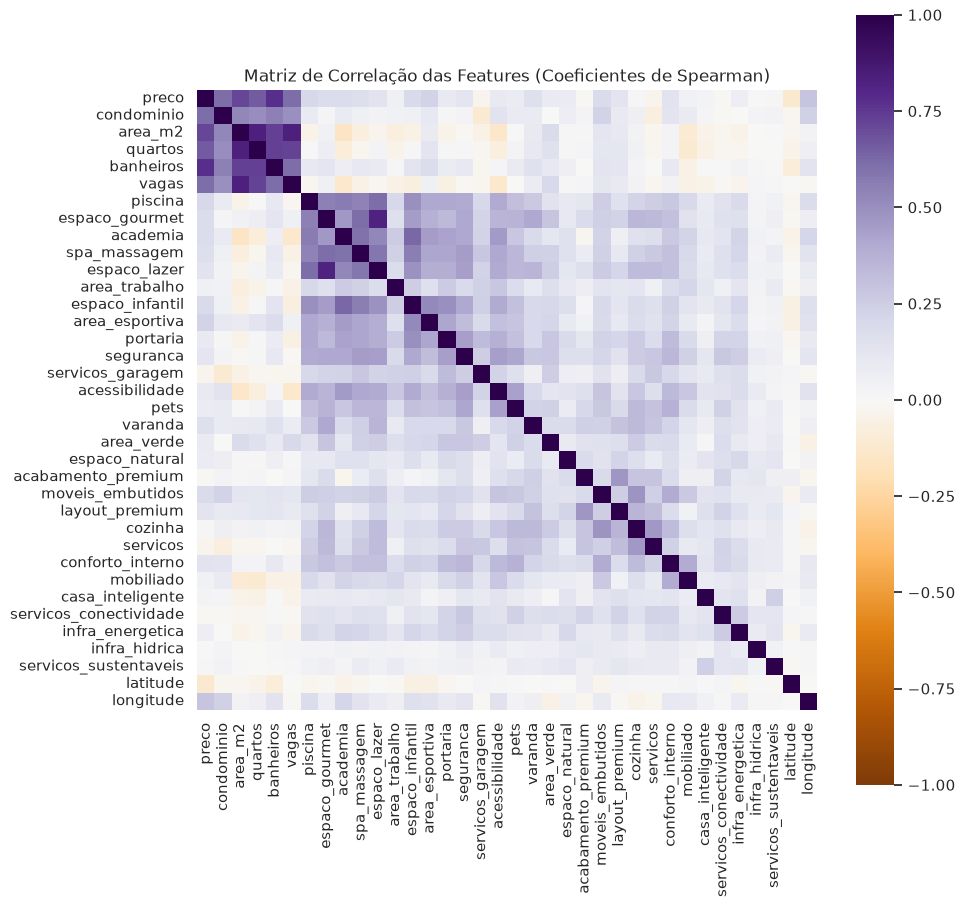

In [64]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

sns.heatmap(
    data=corr,
    annot=False,
    cmap="PuOr",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    ax=ax
)

ax.set_title("Matriz de Correlação das Features (Coeficientes de Spearman)")

plt.show()

Como podemos ver, as features `area_m2`, `banheiros` e `quartos` possuem uma correlação positiva alta com a variável alvo `preço`. Podemos esperar que essas features tenham um bom poder preditivo quando treinarmos nossos modelos, então não seria surpresa se durante a etapa de modelagem nos depararmos com um valor alto de importância para essas features.

Agora, vamos analisar os valores de correlação das primeiras 6 features.

In [65]:
corr_6 = df[df.columns[:6]].corr(method="spearman")

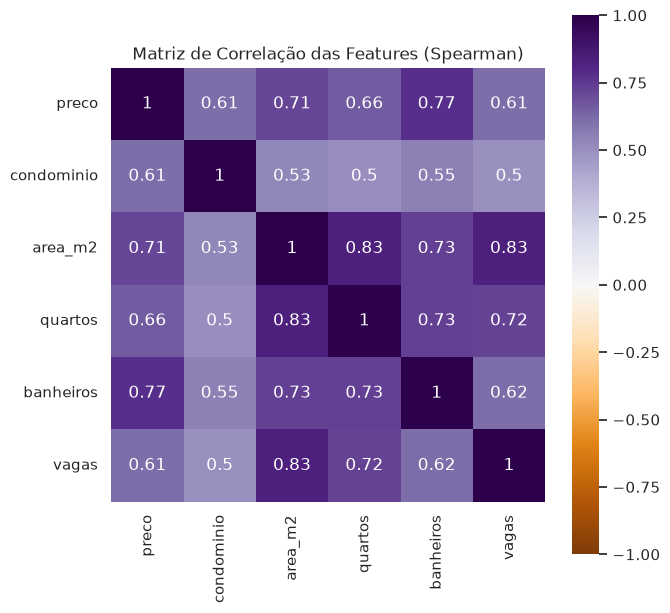

In [66]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7))

sns.heatmap(
    data=corr_6,
    annot=True,
    cmap="PuOr",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    ax=ax
)

ax.set_title("Matriz de Correlação das Features (Spearman)")

plt.show()

Esses valores podem nos dar uma noção de como nossos modelos vão se comportar na etapa de modelagem.

Além disso, vamos análisar a relação entre essas variáveis e o target para entendermos o comportamento do target quando o valor dessas variáveis muda. Isso irá ajudar nosso baseline a ter um desempenho melhor.

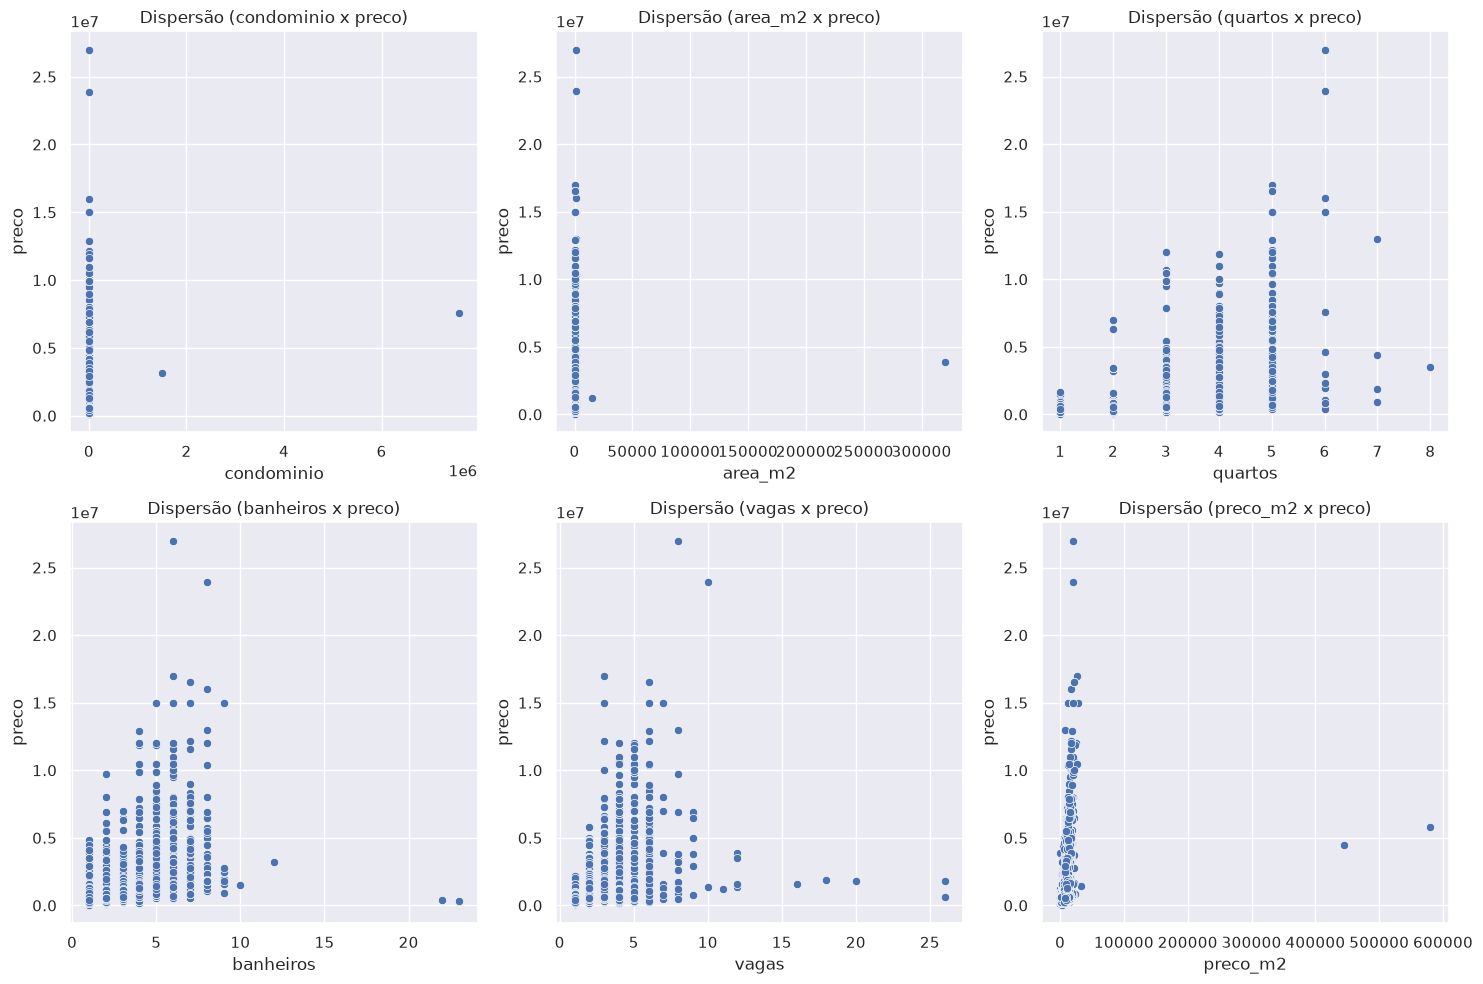

In [67]:
numeric_features = df.columns[:6].to_list()

df_copy = df[numeric_features].copy().astype("float64")
df_copy["preco_m2"] = df_copy["preco"] / df_copy["area_m2"].replace(0, np.nan)
numeric_features.append("preco_m2")

fig, ax = plt.subplots(2, 3, figsize=(15, 10))
ax = ax.flatten()

for i, feature in enumerate(numeric_features[1:]):
    sns.scatterplot(data=df_copy, x=feature, y="preco", ax=ax[i])
    ax[i].set_title(f"Dispersão ({feature} x preco)")

plt.tight_layout()
plt.show()

Como podemos ver, existem alguns valores extremos (os pontos na extrema direita dos scatter plots) nas variáveis que estão atrapalhando nossa análise, portanto precisaremos clipar (winsorizar) essas variáveis para podermos analisar melhor os dados. Faremos a clipagem pelos quartis $0.01$ e $0.99$.

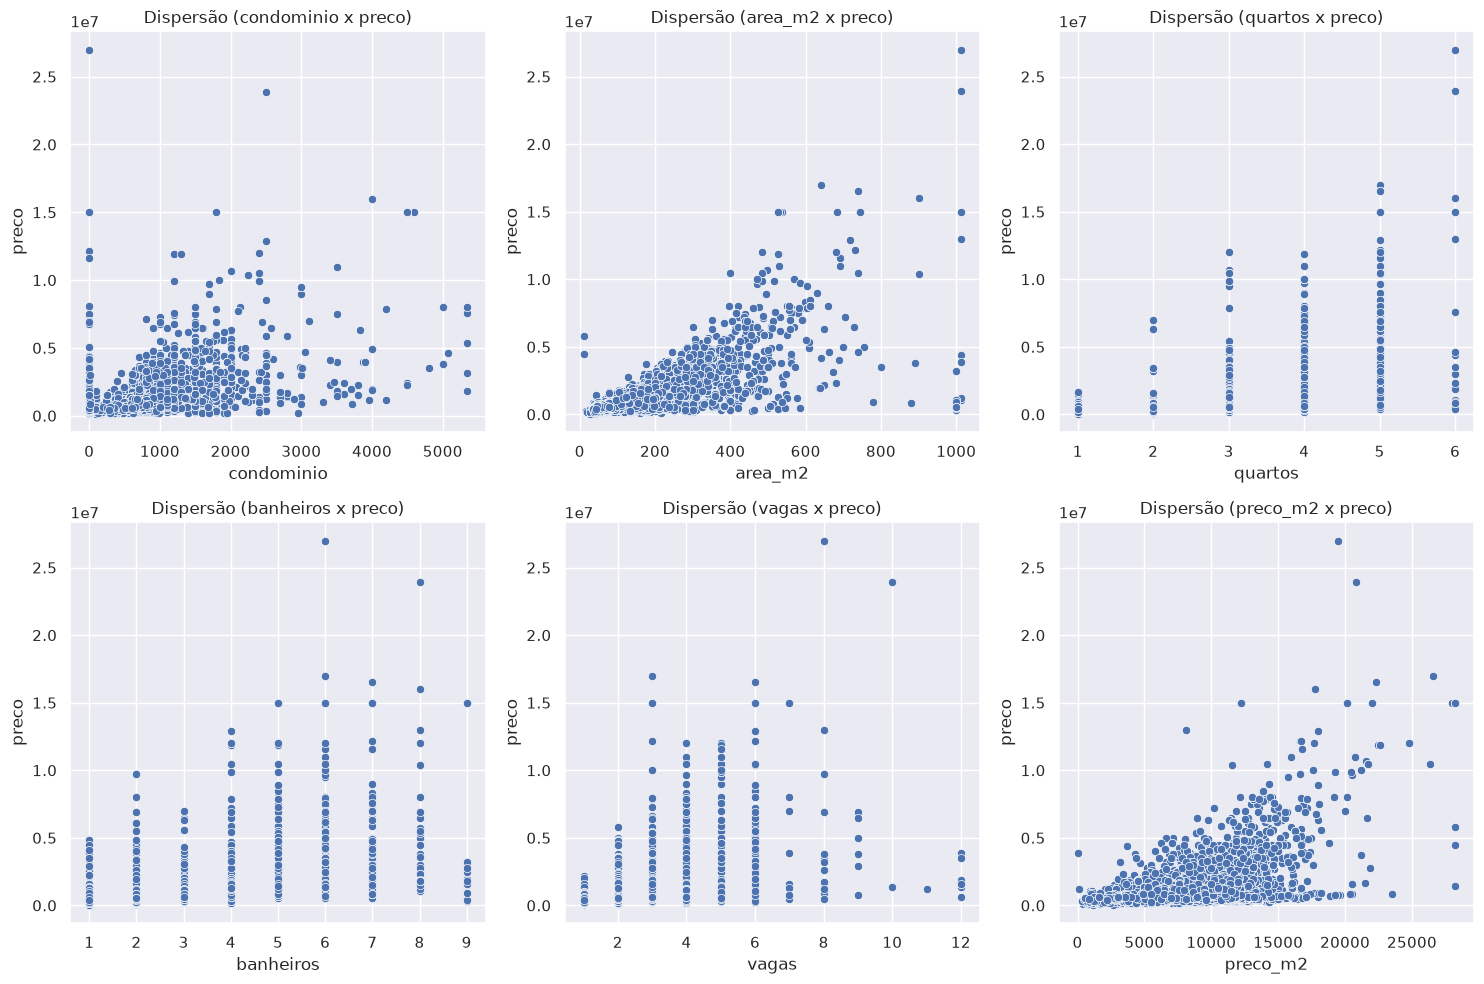

In [68]:
lower = df_copy.quantile(0.0)
upper = df_copy.quantile(0.999)

df_clipped = df_copy[numeric_features[1:]].clip(lower=lower, upper=upper, axis="columns")
df_clipped["preco"] = df_copy["preco"]

fig, ax = plt.subplots(2, 3, figsize=(15, 10))
ax = ax.flatten()

for i, feature in enumerate(numeric_features[1:]):
    sns.scatterplot(data=df_clipped, x=feature, y="preco", ax=ax[i])
    ax[i].set_title(f"Dispersão ({feature} x preco)")

plt.tight_layout()
plt.show()

Agora temos visualizações bem mais informativas. Como podemos ver, todas as variáveis sofrem com heterocedasticidade em relação ao preço, ou seja, a variância do preço muda com o valor das variáveis. Isso é problemático no nosso baseline, já que ele é um modelo linear. Devemos, então, levar isso em consideração na etapa de modelagem. Além disso vou clipar os valores extremos do dataset para prosseguir com as análises.

In [69]:
features = [
    "condominio",
    "area_m2",
    "quartos",
    "banheiros",
    "vagas",
]

df[features] = df[features].astype("float64")

lower = df[features].quantile(0.0)
upper = df[features].quantile(0.999)

df[features] = df[features].clip(
    lower=lower,
    upper=upper,
    axis="columns"
)

## Distribuição das Variáveis

Agora vamos analisar a distribuição das variáveis do nosso dataset para entendermos melhor nossos dados.

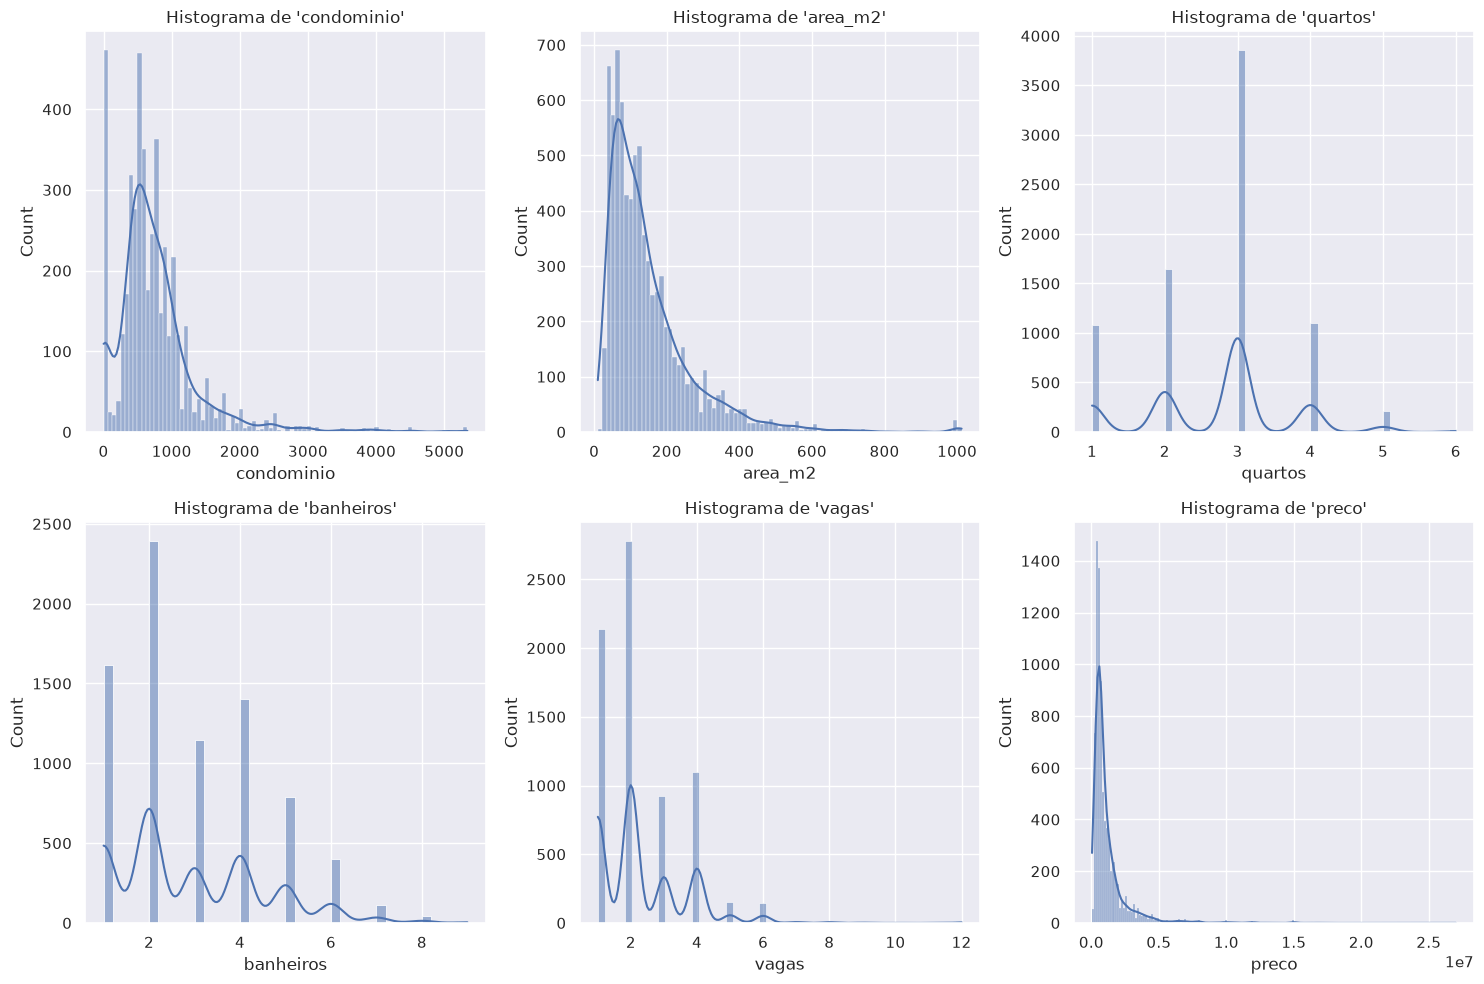

In [70]:
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
ax = ax.flatten()

for i, feature in enumerate(features + ["preco"]):
    sns.histplot(data=df, x=feature, kde=True, ax=ax[i])
    ax[i].set_title(f"Histograma de '{feature}'")

plt.tight_layout()
plt.show()

Como podemos ver, as variáveis `condominio`, `area_m2` e `preco` são altamente assimétricas e possuem caudas longas. Isso pode ser particularmente problemático para nossos modelos de regressão pois os outliers desses dados podem influenciar negativamente esses modelos. Vamos olhar como essas variáveis ficariam com algumas transformações: padronização, transformação logarítimica, box-cox e yeo-johnson.

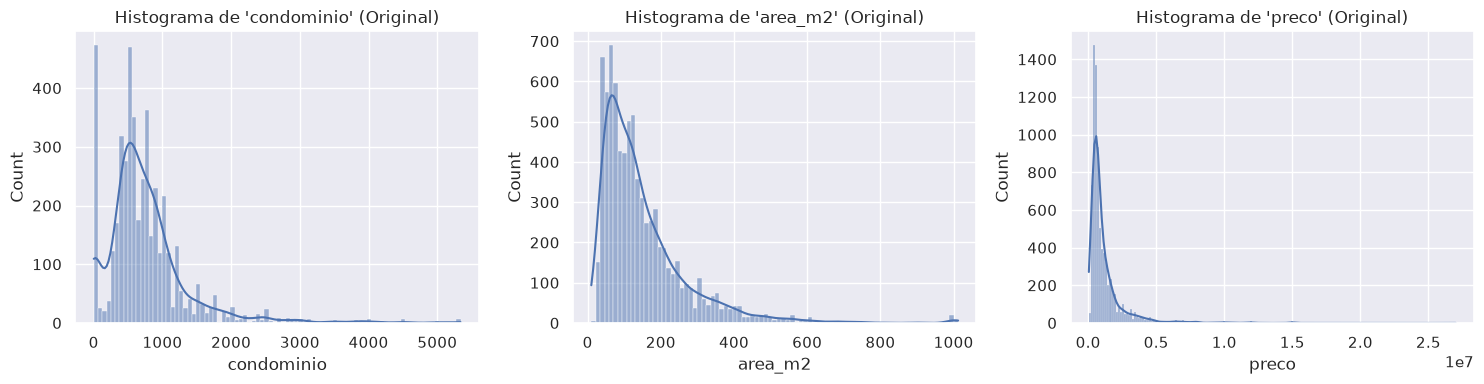

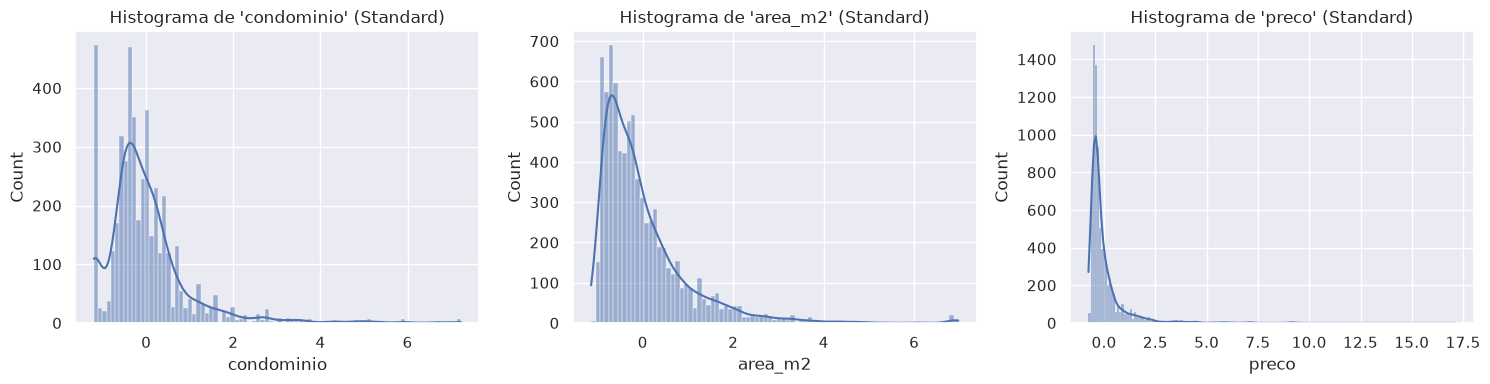

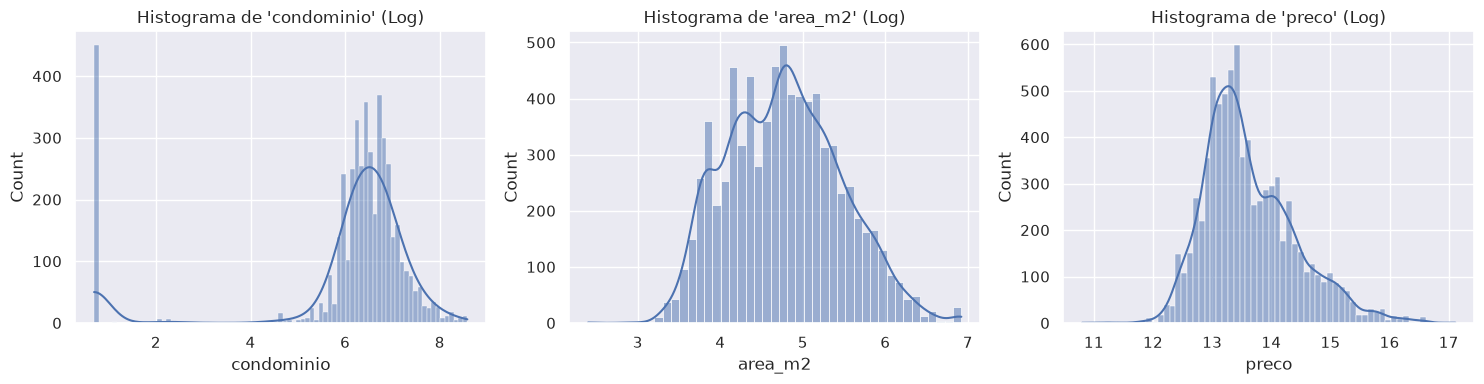

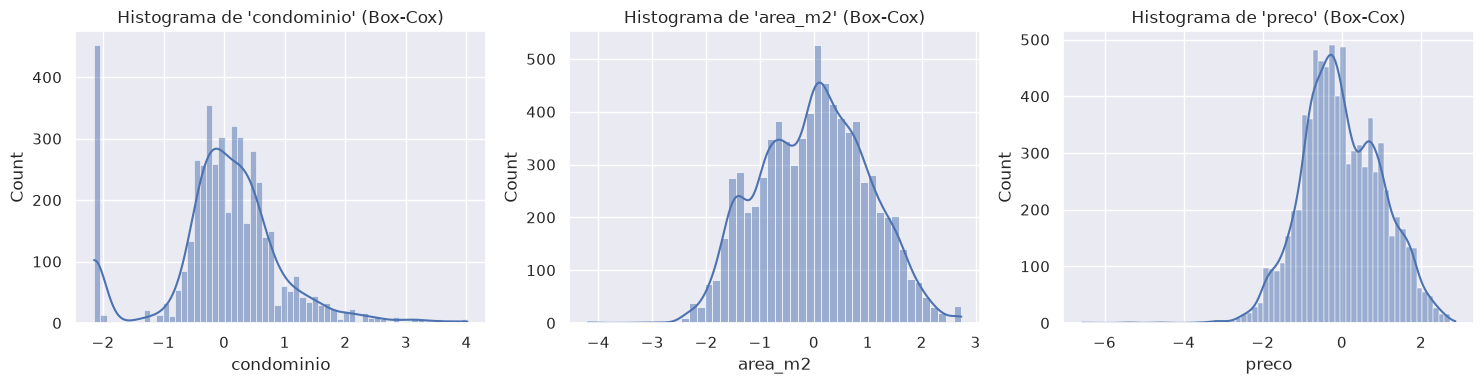

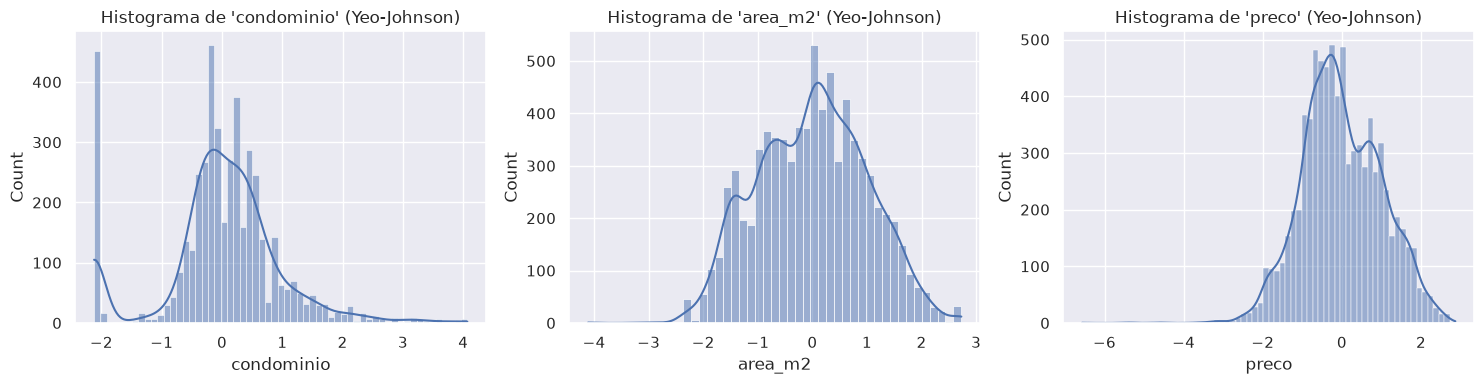

In [71]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import FunctionTransformer

features = ["condominio", "area_m2", "preco"]

def plot_histogram(data, name):
    data = pd.DataFrame(data.copy(), columns=features)

    _, ax = plt.subplots(1, 3, figsize=(15, 4))
    ax = ax.flatten()

    for i, feature in enumerate(features):
        sns.histplot(data=data, x=feature, kde=True, ax=ax[i])
        ax[i].set_title(f"Histograma de '{feature}' ({name})")

    plt.tight_layout()
    plt.show()

scaler = StandardScaler()
box_cox = PowerTransformer(method="box-cox")
yeo_johnson = PowerTransformer(method="yeo-johnson")
log = FunctionTransformer(func=np.log1p)

data = df[features]

data_scaler = scaler.fit_transform(data)
data_log = log.fit_transform(data)
data_box_cox = box_cox.fit_transform(data)
data_yeo_johson = yeo_johnson.fit_transform(data)

plot_histogram(data, "Original")
plot_histogram(data_scaler, "Standard")
plot_histogram(data_log, "Log")
plot_histogram(data_box_cox, "Box-Cox")
plot_histogram(data_yeo_johson, "Yeo-Johnson")

Com essas features transformadas, provavelmente nossos modelos de regressão terão um desempenho superior ao modelos sem essas transformações.

## Análise de Agregação

Agora, vamos analisar nosso target agregado em agrupamentos das nossas features. Iremos agrupar pelas features `tipo_imovel`, `quartos`, `banheiros`, `vagas` e `bairro`.

In [72]:
df1 = pd.read_parquet("../data/processed/01_cleaned.parquet", columns=["bairro"])

df["bairro"] = df1["bairro"]
df["tipo_imovel"] = tipo_imovel

features = ["tipo_imovel", "quartos", "banheiros", "vagas", "bairro"]

for feature in features:
    print(df
        .groupby(feature)["preco"]
        .describe()
        .sort_values(by="mean", ascending=False)
        .round(0)
        .to_string(),
        end="\n\n"
    )

              count       mean        std       min        25%        50%        75%         max
tipo_imovel                                                                                     
cobertura     589.0  3129432.0  2909710.0  430000.0  1350000.0  2250000.0  3600000.0  16500000.0
outro          76.0  1484012.0  2089868.0  185000.0   496718.0   875000.0  1790000.0  15000000.0
casa         3225.0  1291479.0  1590866.0   86266.0   450000.0   750000.0  1500000.0  27000000.0
sobrado       153.0   993203.0   502888.0  350000.0   640000.0   845000.0  1280000.0   4200000.0
apartamento  3050.0   921448.0   710978.0   49000.0   525000.0   700000.0  1150000.0  12000000.0
studio         54.0   528847.0   103424.0  330000.0   445900.0   510000.0   607500.0    750000.0
flat          772.0   481546.0   149348.0   68000.0   380000.0   490000.0   595000.0   1100000.0

          count       mean        std       min        25%        50%         75%         max
quartos                         

E vamos plotar também os histogramas de cada agrupamento.

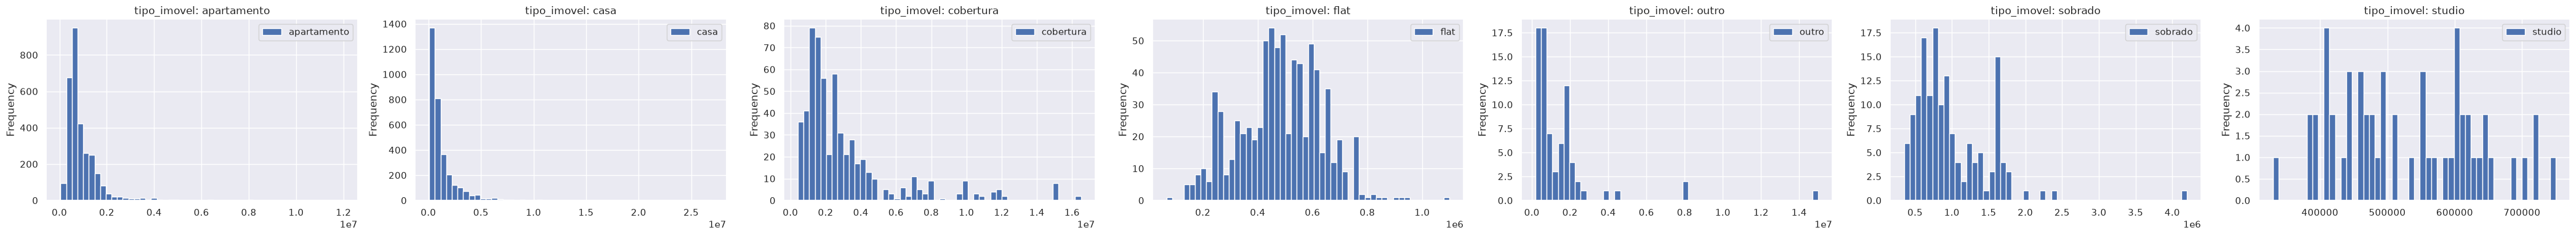

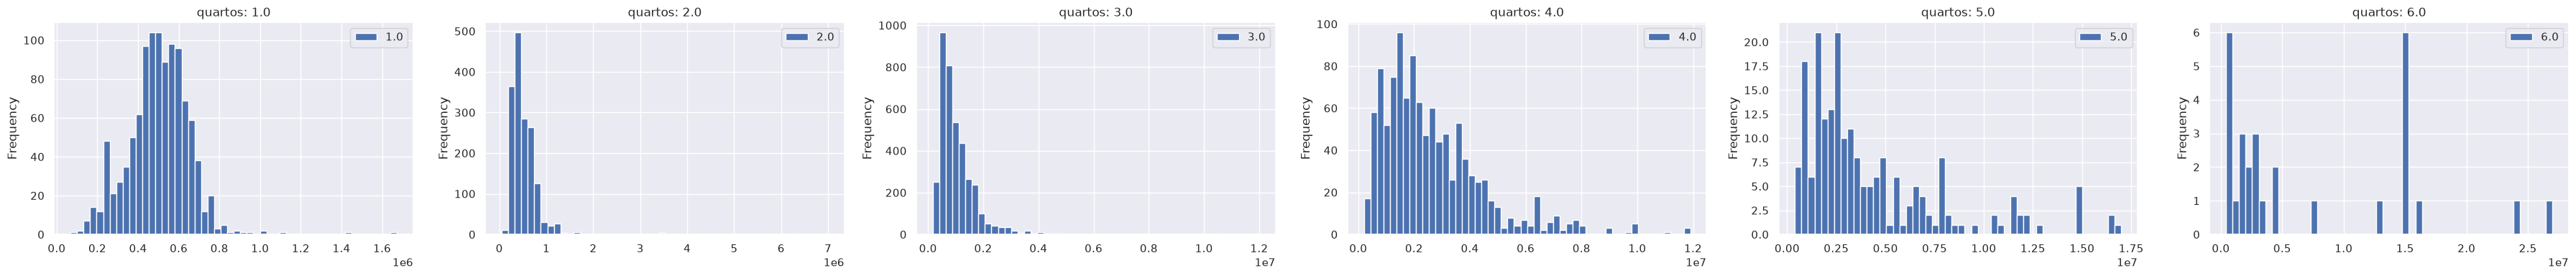

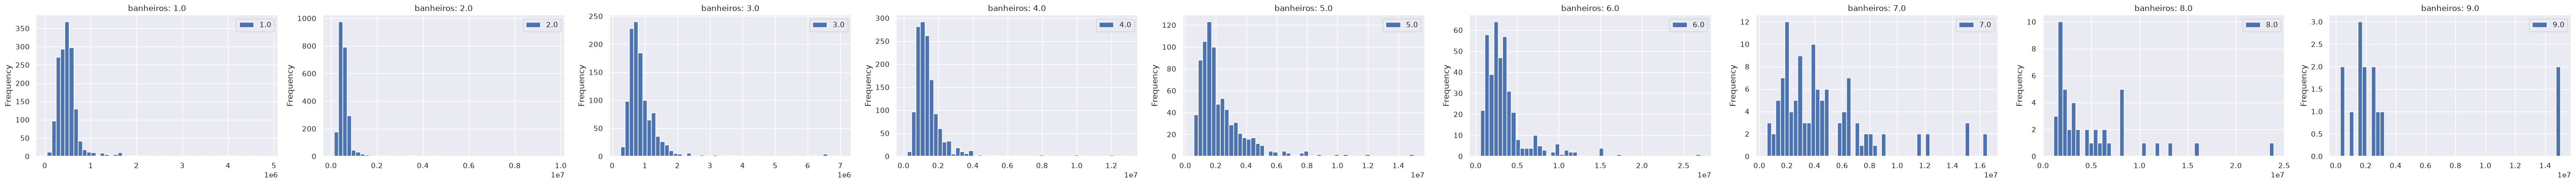

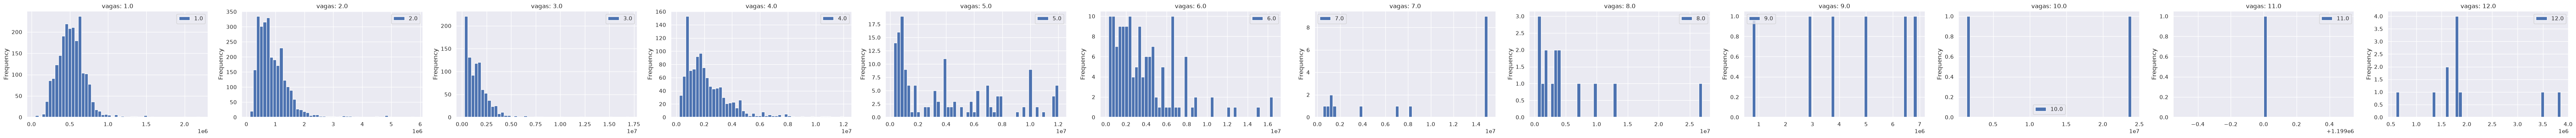

In [73]:
features = ["tipo_imovel", "quartos", "banheiros", "vagas"]

for feature in features:
    groups = df.groupby(feature)
    n = len(groups)

    fig, ax = plt.subplots(1, n, figsize=(6*n, 4))

    for i, (label, group) in enumerate(groups):
        group["preco"].plot(
            kind="hist",
            bins=50,
            ax=ax[i],
            label=label
        )

        ax[i].set_title(f"{feature}: {label}")
        ax[i].legend()

    plt.tight_layout()
    plt.show()

## Análise de Dados Faltantes

Agora vamos olhar para os dados faltantes do nosso dataset. Primeiro, vamos olhar as porcentagens de dados faltantes nas features do nosso dataset.

In [74]:
df_na_count = df.isna().sum()
total = df.shape[0]

df_missing = pd.DataFrame({
    "Contagem de NA": df_na_count,
    "Porcentagem": (100*df_na_count / total).round(2),
})

df_missing = df_missing.sort_values(
    by="Contagem de NA",
    ascending=False
)

print(df_missing.to_string())

                        Contagem de NA  Porcentagem
bairro                            4674        59.02
condominio                        3317        41.89
vagas                              633         7.99
banheiros                            1         0.01
quartos                              1         0.01
preco                                0         0.00
area_m2                              0         0.00
piscina                              0         0.00
academia                             0         0.00
espaco_gourmet                       0         0.00
espaco_lazer                         0         0.00
area_trabalho                        0         0.00
espaco_infantil                      0         0.00
spa_massagem                         0         0.00
portaria                             0         0.00
seguranca                            0         0.00
servicos_garagem                     0         0.00
acessibilidade                       0         0.00
pets        

Como podemos ver, apenas as features `condominio`, `vagas`, `banheiros` e `quartos` possuem valores faltantes, sendo os $2$ últimos de baixíssima frequência. Como as duas últimas possuem uma quantidade muito baixa de valores faltantes, então vamos prosseguir a análise apenas com as $2$ primeiras features.

In [75]:
df_miss = df[["condominio", "vagas"]]

<Axes: >

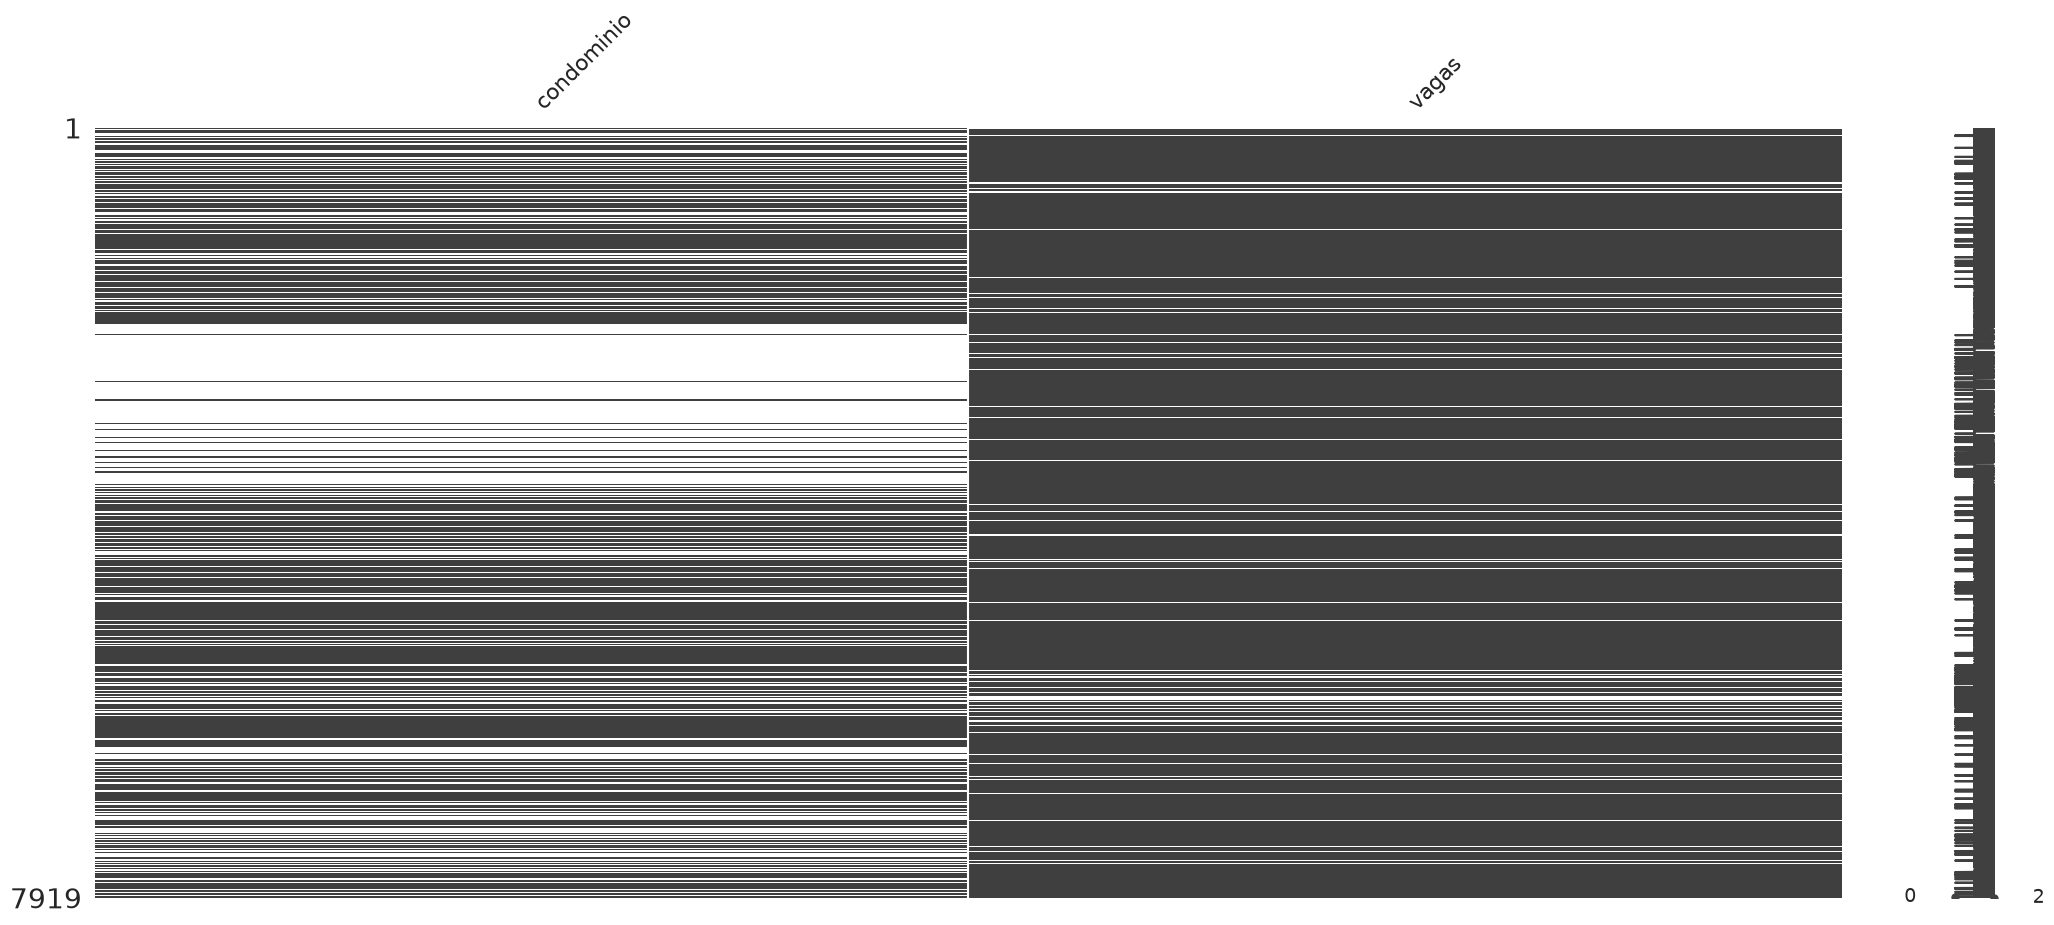

In [76]:
msno.matrix(df_miss)

Bom, a princípio não parece ter nenhum padrão nos valores faltantes. Vamos então olhar para as correlações dos valores faltantes dessas features.

<Axes: >

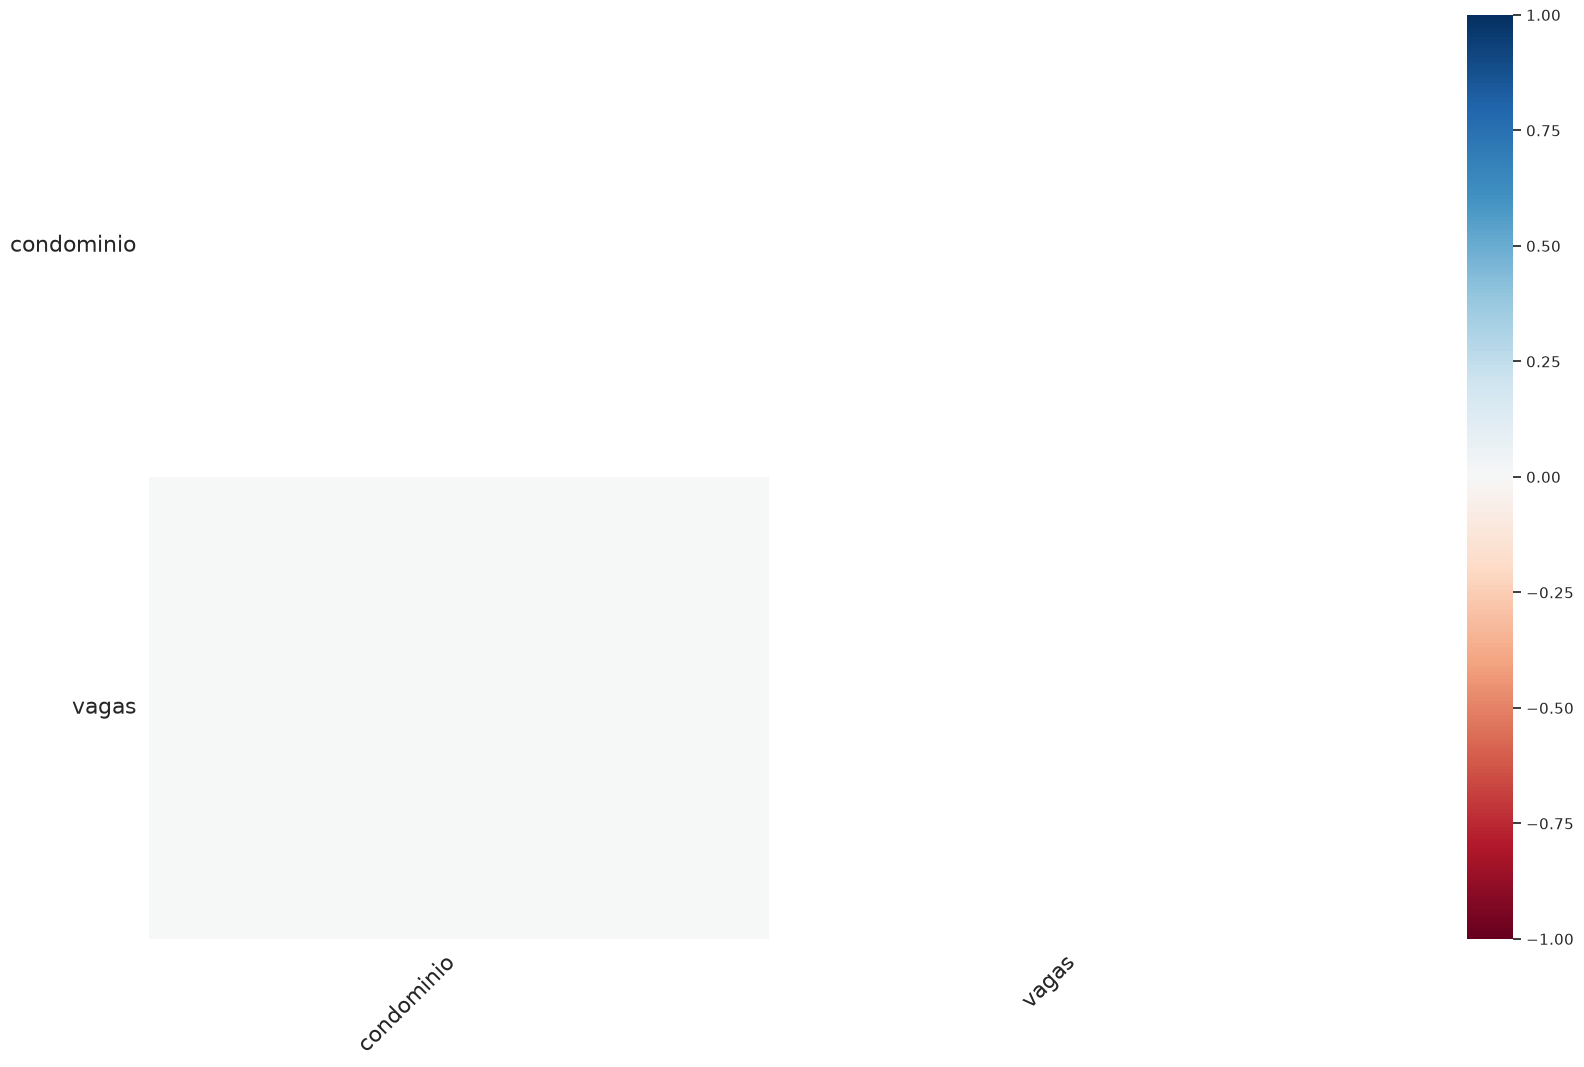

In [77]:
msno.heatmap(df_miss)

Como podemos ver, as duas variáveis não tem quase correlação nenhuma nos seus dados faltantes.

Com essas informações podemos concluir que não existe relação entre os valores faltantes de `vagas` e `condominio`. Além disso, existem muito valores faltantes na variável `condominio`, o que pode ser um problema na etapa de modealgem. Entretanto, por enquanto não faremos nada com os valores faltantes.

## Análise de Outliers

Para fazermos a análise de outliers, vamos treinar um modelo de aprendizado não supervisionado chamado Isolation Forest, que é um modelo de detecção de anomalias.

Antes vamos adicionar também a feature `preco_m2`, para calcular o preço por metro quadrado do imóvel.

In [80]:
df["preco_m2"] = df["preco"] / df["area_m2"].replace(0, np.nan)

Agora vamos montar nosso pipeline de detecção de anomalias com o `IsolationForest`.

In [96]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import IsolationForest
from sklearn.impute import (
    SimpleImputer,
)

random_state = 1667

numeric_columns = df.select_dtypes(include=["number", "boolean"]).columns.to_list()
categorical_columns = ["tipo_imovel"]

imputer = SimpleImputer(
    strategy="median"
)

detector = IsolationForest(
    contamination=0.01,
    n_estimators=5000,
    max_samples=0.25,
    random_state=random_state,
    verbose=1,
)

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_columns),
        ("categorical", categorical_pipeline, categorical_columns),
    ],
    remainder="drop",
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("detector", detector)
])

In [97]:
X = df.copy()

E vamos treinar nosso modelo.

In [98]:
pipeline.fit(X)

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    9.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done 1249 tasks      | elapsed:    0.7s
[Parallel(n_jobs=1)]: Done 1799 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done 2449 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done 3199 tasks      | elapsed:    1.8s
[Parallel(n_jobs=1)]: Done 4049 tasks      | elapsed:    2.2s
[Parallel(n_jobs=1)]: Done 4999 tasks      | elapsed:    2.7s
[Parallel(n_jobs=1)]: Done 5000 out of 5000 | elapsed:    2.7s finished


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('detector', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](39,)","['preco','condominio','area_m2',...,'bairro','tipo_imovel','preco_m2']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,39
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This sub

Calcular as previões de outliers.

In [99]:
outlier = pipeline.predict(X)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done 1249 tasks      | elapsed:    0.7s
[Parallel(n_jobs=1)]: Done 1799 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done 2449 tasks      | elapsed:    1.4s
[Parallel(n_jobs=1)]: Done 3199 tasks      | elapsed:    1.8s
[Parallel(n_jobs=1)]: Done 4049 tasks      | elapsed:    2.2s
[Parallel(n_jobs=1)]: Done 4999 tasks      | elapsed:    2.7s
[Parallel(n_jobs=1)]: Done 5000 out of 5000 | elapsed:    2.7s finished


E vamos adicionar essas informações no nosso dataset, para plotarmos alguns gráficos mais adiante.

In [100]:
df_copy = df.copy()

df_copy["outlier"] = outlier
df_copy["outlier"] = df_copy["outlier"].map({1: "normal", -1: "outlier"})

df_copy = df_copy.sort_values(by="outlier")

Agora, vamos plotar alguns gráficos de dispersão para entendermos melhor esses outliers.

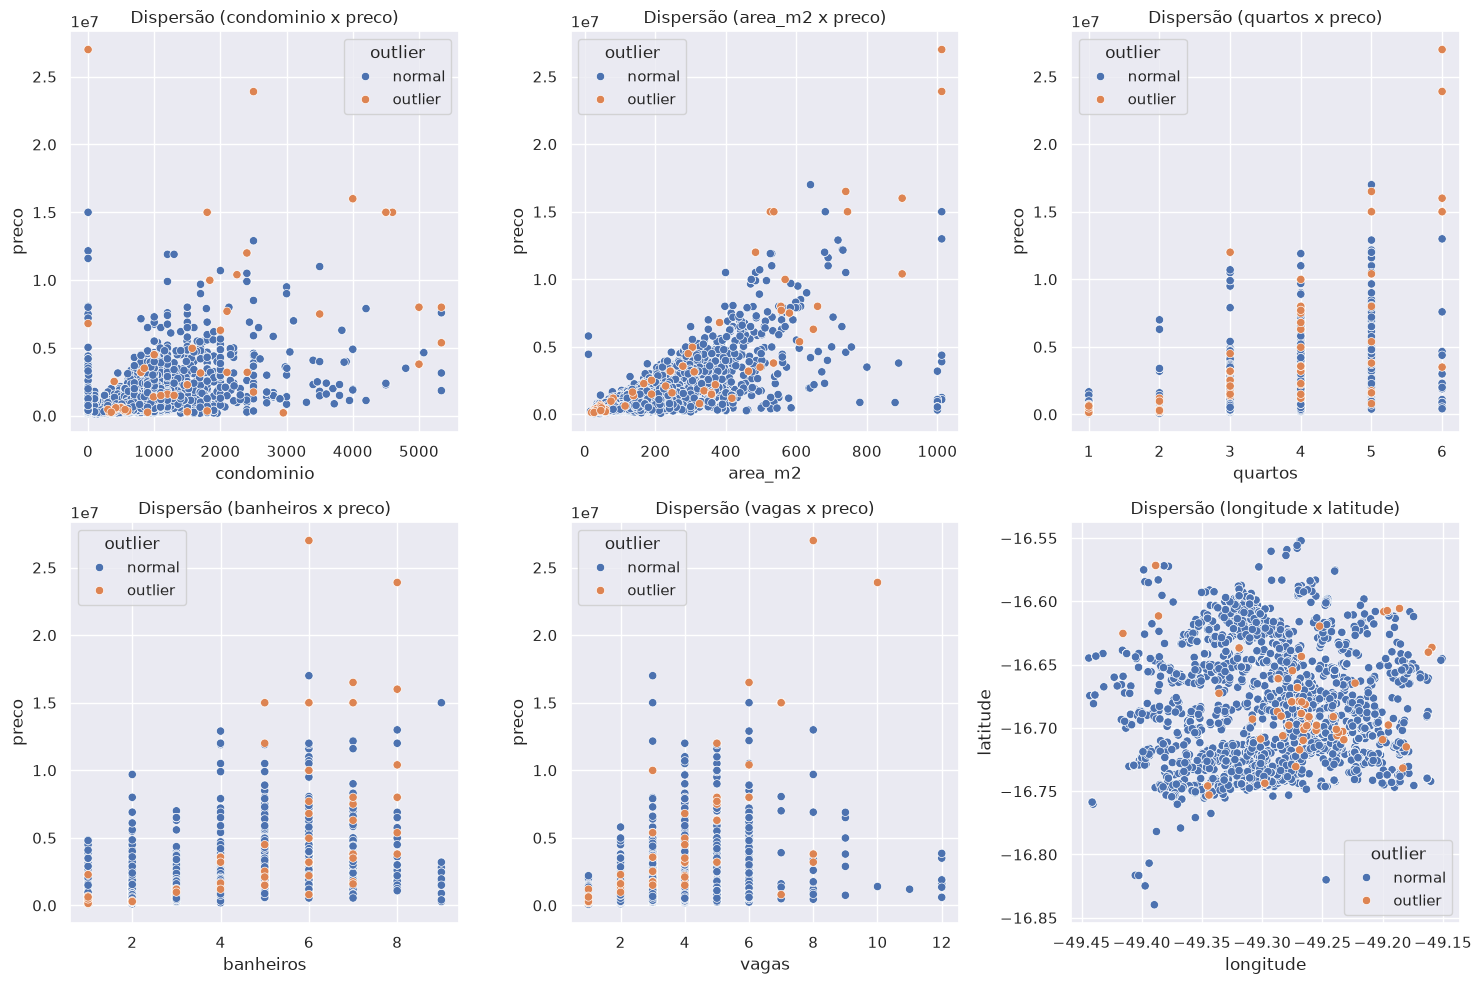

In [101]:
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
ax = ax.flatten()

for i, feature in enumerate(["condominio", "area_m2", "quartos", "banheiros", "vagas"]):
    sns.scatterplot(data=df_copy, x=feature, y="preco", hue="outlier", ax=ax[i])
    ax[i].set_title(f"Dispersão ({feature} x preco)")

sns.scatterplot(data=df_copy, x="longitude", y="latitude", hue="outlier", ax=ax[5])
ax[5].set_title("Dispersão (longitude x latitude)")

plt.tight_layout()
plt.show()

Como podemos ver, existem alguns outliers de `preco`, mas não parece haver nenhum padrão nos outliers dos primeiros $4$ gráficos. Agora no último temos alguns agrupamentos dos outliers que provavelmente indicam imóveis com preços muito altos. Os pontos mais isolados podem significar imóveis muito baratos. Por enquanto não faremos nada aos outliers, pois eles podem conter informação preditica relevante.